In [2]:
# Imports
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['figure.figsize'] = (15.0, 8.0) # set default size of plots
plt.rcParams['figure.facecolor'] = 'white'

matplotlib.rcParams.update({'font.size': 15})

In [3]:
TIME_RETRIEVAL_REE = 0
TIME_RETRIEVAL_TEE = 5
TIME_RETRIEVAL_REE_WASM = 0
TIME_RETRIEVAL_TEE_WASM = 5

In [4]:
def compute_mean_std(name, time):
    df = pd.DataFrame(columns = ["Name","Time"])
    df["Name"] = pd.to_numeric(name)
    df["Time"] = time
    
    result = pd.DataFrame(columns = ["Mean","Std"])
    result["Mean"] = df.groupby("Name")["Time"].median() #df.groupby("Size")["Time"].apply(stats.gmean)
    result["Std"] = df.groupby("Name")["Time"].std() #df.groupby("Size")["Time"].apply(stats.gstd)
    
    return result

def formatForLatex(n, digits_round = 3):
    roundedAsString = str(round(n, digits_round))
    if "." in roundedAsString:
        roundedAsString = roundedAsString.rstrip("0")
        roundedAsString = roundedAsString.rstrip(".")
    return f"{roundedAsString}"

In [5]:
#
## TEE (Wasm) dataset
#

In [6]:
# Import the dataset
tee_wasm_raw = pd.read_csv("../logs/speedtest1/tee-wasm.csv", names = ["Name","Time"])
tee_wasm_raw["Name"] = tee_wasm_raw["Name"]

tee_wasm_raw

,Name,Time
0,100,50771
1,110,76148
2,120,102853
3,130,68626
4,140,136008
...,...,...
1545,500,125127
1546,510,105815
1547,520,75729
1548,980,270762


In [7]:
# Adapt the time according the retrieval of the time
tee_wasm = tee_wasm_raw

tee_wasm["Time"] = tee_wasm["Time"] - 2*TIME_RETRIEVAL_TEE_WASM/2

# Drop any error in the logs
# tee_wasm.drop(tee_wasm[tee_wasm.Name.str.contains("failed")].index, inplace = True)
tee_wasm = tee_wasm.reset_index()

tee_wasm

,index,Name,Time
0,0,100,50766.0
1,1,110,76143.0
2,2,120,102848.0
3,3,130,68621.0
4,4,140,136003.0
...,...,...,...
1545,1545,500,125122.0
1546,1546,510,105810.0
1547,1547,520,75724.0
1548,1548,980,270757.0


In [8]:
#
## TEE (Native) dataset
#

In [9]:
# Import the dataset
tee_native_raw = pd.read_csv("../logs/speedtest1/tee-native.csv", names = ["Name","Time"])
tee_native_raw["Name"] = tee_native_raw["Name"]

# Trim to results to match TEE logs, which may have been trimmed because of errors
tee_native_raw.drop(tee_native_raw.index[len(tee_wasm.index):], inplace = True)

tee_native_raw

,Name,Time
0,100,48603
1,110,67741
2,120,89462
3,130,56805
4,140,115610
...,...,...
1545,500,119151
1546,510,97311
1547,520,77052
1548,980,239672


In [10]:
# Adapt the time according the retrieval of the time
tee_native = tee_native_raw

tee_native["Time"] = tee_native["Time"] - 2*TIME_RETRIEVAL_TEE/2

tee_native

,Name,Time
0,100,48598.0
1,110,67736.0
2,120,89457.0
3,130,56800.0
4,140,115605.0
...,...,...
1545,500,119146.0
1546,510,97306.0
1547,520,77047.0
1548,980,239667.0


In [11]:
#
## REE (Native) dataset
#

In [12]:
# Import the dataset
ree_native_raw = pd.read_csv("../logs/speedtest1/ree-native.csv", names = ["Name","Time"])
ree_native_raw["Name"] = ree_native_raw["Name"]

# Trim to results to match TEE logs, which may have been trimmed because of errors
ree_native_raw.drop(ree_native_raw.index[len(tee_wasm.index):], inplace = True)

ree_native_raw

,Name,Time
0,100,27842
1,110,38872
2,120,49971
3,130,38007
4,140,78676
...,...,...
1545,500,63603
1546,510,59907
1547,520,32019
1548,980,178505


In [13]:
# Adapt the time according the retrieval of the time
ree_native = ree_native_raw

ree_native["Time"] = ree_native["Time"] - 2*TIME_RETRIEVAL_REE/2

ree_native

,Name,Time
0,100,27842.0
1,110,38872.0
2,120,49971.0
3,130,38007.0
4,140,78676.0
...,...,...
1545,500,63603.0
1546,510,59907.0
1547,520,32019.0
1548,980,178505.0


In [14]:
#
## REE (Wasm) dataset
#

In [15]:
# Import the dataset
ree_wasm_raw = pd.read_csv("../logs/speedtest1/ree-wasm.csv", names = ["Name","Time"])
ree_wasm_raw["Name"] = ree_wasm_raw["Name"]

# Trim to results to match TEE logs, which may have been trimmed because of errors
ree_wasm_raw.drop(ree_wasm_raw.index[len(tee_wasm.index):], inplace = True)

ree_wasm_raw

,Name,Time
0,100,45698
1,110,67108
2,120,84031
3,130,69006
4,140,117615
...,...,...
1545,500,110032
1546,510,110228
1547,520,56748
1548,980,267617


In [17]:
# Adapt the time according the retrieval of the time
ree_wasm = ree_wasm_raw

ree_wasm["Time"] = ree_wasm["Time"] - 2*TIME_RETRIEVAL_REE_WASM/2

ree_wasm

,Name,Time
0,100,45698.0
1,110,67108.0
2,120,84031.0
3,130,69006.0
4,140,117615.0
...,...,...
1545,500,110032.0
1546,510,110228.0
1547,520,56748.0
1548,980,267617.0


In [18]:
#
## Export
#

In [19]:
# Normalize the results based on REE time
ree_native_normalized = pd.DataFrame()
ree_wasm_normalized = pd.DataFrame()
tee_native_normalized = pd.DataFrame()
tee_wasm_normalized = pd.DataFrame()
for col in ree_native:
    if col == "Name":
        tee_wasm_normalized[col] = tee_wasm[col]
        ree_wasm_normalized[col] = ree_wasm[col]
        tee_native_normalized[col] = tee_native[col]
        ree_native_normalized[col] = ree_native[col]
    else:
        tee_wasm_normalized[col] = tee_wasm[col] / ree_native[col]
        ree_wasm_normalized[col] = ree_wasm[col] / ree_native[col]
        tee_native_normalized[col] = tee_native[col] / ree_native[col]
        ree_native_normalized[col] = 1
    
tee_wasm_normalized

,Name,Time
0,100,1.823360
1,110,1.958814
2,120,2.058154
3,130,1.805483
4,140,1.728647
...,...,...
1545,500,1.967234
1546,510,1.766238
1547,520,2.364971
1548,980,1.516803


In [20]:
# Compute the mean and std
ree_native_export = pd.DataFrame()

ree_native_export = pd.concat([ree_native_export, compute_mean_std(ree_native_normalized["Name"], ree_native_normalized["Time"])])
ree_native_export

,Mean,Std
Name,,
100,1.0,0.0
110,1.0,0.0
120,1.0,0.0
130,1.0,0.0
140,1.0,0.0
142,1.0,0.0
145,1.0,0.0
150,1.0,0.0
160,1.0,0.0


In [21]:
# Compute the mean and std
ree_wasm_export = pd.DataFrame()

ree_wasm_export = pd.concat([ree_wasm_export, compute_mean_std(ree_wasm_normalized["Name"], ree_wasm_normalized["Time"])])
ree_wasm_export

,Mean,Std
Name,,
100,1.592446,0.100544
110,1.717016,0.024095
120,1.669608,0.020818
130,1.805789,0.008390
140,1.499247,0.010338
142,1.541740,0.005859
145,1.409941,0.008137
150,1.640560,0.013286
160,1.490235,0.012525


In [22]:
# Compute the mean and std
tee_wasm_export = pd.DataFrame()

tee_wasm_export = pd.concat([tee_wasm_export, compute_mean_std(tee_wasm_normalized["Name"], tee_wasm_normalized["Time"])])
tee_wasm_export

,Mean,Std
Name,,
100,1.720316,0.536672
110,1.907897,0.042283
120,2.035969,0.036394
130,1.800279,0.007964
140,1.727603,0.013355
142,1.732362,0.006637
145,1.518048,0.011576
150,1.970820,0.025403
160,1.530445,0.017843


In [23]:
# Compute the mean and std
tee_native_export = pd.DataFrame()

tee_native_export = pd.concat([tee_native_export, compute_mean_std(tee_native_normalized["Name"], tee_native_normalized["Time"])])
tee_native_export

,Mean,Std
Name,,
100,1.729140,0.282647
110,1.751153,0.021907
120,1.810828,0.296139
130,1.492199,0.282151
140,1.466480,0.244698
142,1.348053,0.233172
145,1.355194,0.301980
150,1.740942,0.301234
160,1.351326,0.197096


In [24]:
#
## Temp visualisation
#

In [1]:
tee_native_export = tee_native_export.loc[~tee_native_export.index.isin([210, 250,260])]
ree_native_export = ree_native_export.loc[~ree_native_export.index.isin([210, 250,260])]
ree_wasm_export = ree_wasm_export.loc[~ree_wasm_export.index.isin([210, 250,260])]
tee_wasm_export = tee_wasm_export.loc[~tee_wasm_export.index.isin([210, 250,260])]

NameError: name 'tee_native_export' is not defined

(0.9, 10.168950829270807)

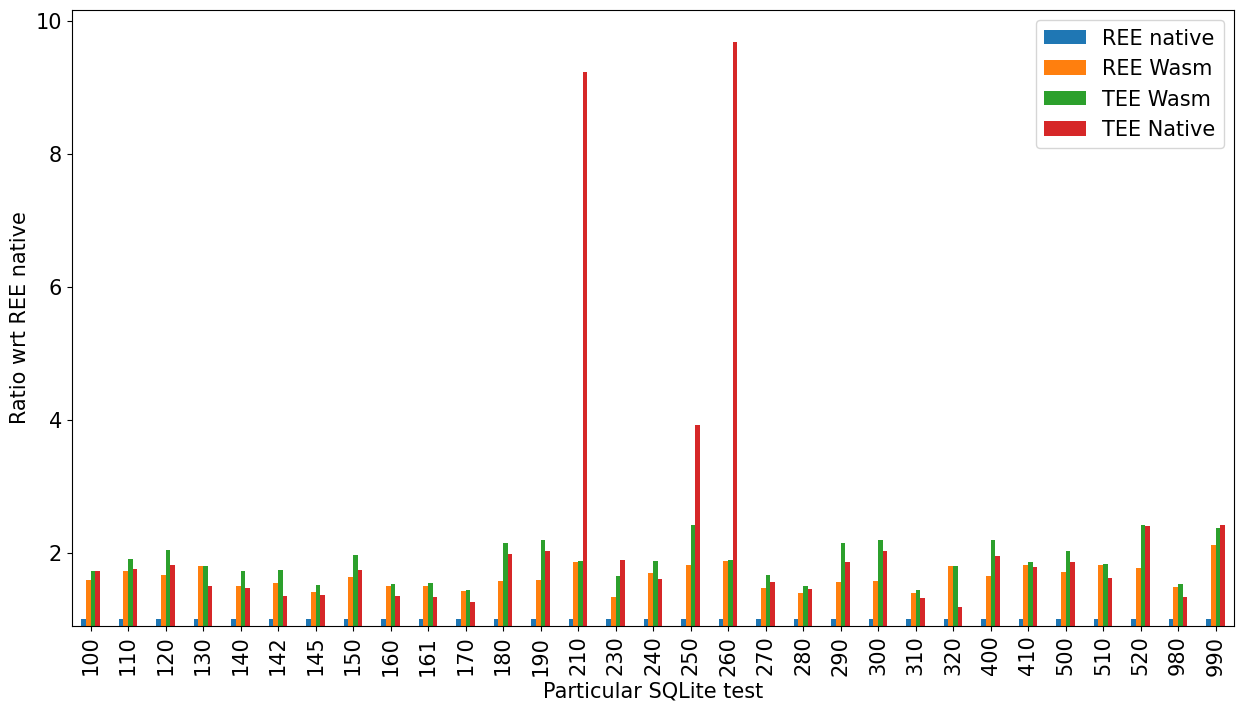

In [25]:
df = pd.DataFrame({'REE native': ree_native_export["Mean"],
                   'REE Wasm': ree_wasm_export["Mean"],
                   'TEE Wasm': tee_wasm_export["Mean"],
                   'TEE Native': tee_native_export["Mean"]}, index=ree_native_export.index.values)
ax = df.plot.bar()
ax.set_xlabel("Particular SQLite test")
ax.set_ylabel("Ratio wrt REE native")
ax.set_ylim(0.9)

In [109]:
# Retrieve the name of the experiment, order by TEE normalized run time
tee_wasm_indexes = tee_wasm_export.sort_values(by=["Mean"]).index
tee_wasm_indexes

Index([310, 170, 280, 145, 980, 160, 161, 230, 270, 100, 140, 142, 320, 130,
       510, 410, 240, 110, 150, 500, 120, 180, 290, 400, 300, 190, 990, 520],
      dtype='int64', name='Name')

In [110]:
# Order the entries based on the TEE normalized run time
ree_wasm_export = ree_wasm_export.reindex(tee_wasm_indexes)
tee_wasm_export = tee_wasm_export.reindex(tee_wasm_indexes)
tee_native_export = tee_native_export.reindex(tee_wasm_indexes)

In [113]:
# Compute values for the paper

def get_mean_of_experiment(name):
    return tee_wasm_export.loc[tee_wasm_export.index == name]["Mean"].values[0]

tee_wasm_mean_of_mean = tee_wasm_export["Mean"].mean()
ree_wasm_mean_of_mean = ree_wasm_export["Mean"].mean()
tee_native_mean_of_mean = tee_native_export["Mean"].mean()
tee_wasm_and_tee_native_ratio = tee_wasm_mean_of_mean / tee_native_mean_of_mean

tee_wasm_insert_mean = pd.DataFrame(
[
    get_mean_of_experiment(100),
    get_mean_of_experiment(110),
    get_mean_of_experiment(120),
    get_mean_of_experiment(180),
    get_mean_of_experiment(190),
    # get_mean_of_experiment(210),
    get_mean_of_experiment(290),
    get_mean_of_experiment(300),
    get_mean_of_experiment(400),
    get_mean_of_experiment(500)
]).mean()

tee_wasm_index_mean = pd.DataFrame(
[
    get_mean_of_experiment(110),
    get_mean_of_experiment(120),
    get_mean_of_experiment(160),
    get_mean_of_experiment(161),
    get_mean_of_experiment(170),
    get_mean_of_experiment(180),
    get_mean_of_experiment(230),
    get_mean_of_experiment(270),
    get_mean_of_experiment(400),
    get_mean_of_experiment(410),
    get_mean_of_experiment(500),
    get_mean_of_experiment(510)
]).mean()

tee_wasm_select_mean = pd.DataFrame(
[
    get_mean_of_experiment(130),
    get_mean_of_experiment(140),
    get_mean_of_experiment(142),
    get_mean_of_experiment(145),
    get_mean_of_experiment(160),
    get_mean_of_experiment(161),
    get_mean_of_experiment(170),
    # get_mean_of_experiment(260),
    get_mean_of_experiment(310),
    get_mean_of_experiment(320),
    get_mean_of_experiment(410),
    get_mean_of_experiment(510),
    get_mean_of_experiment(520)
]).mean()
tee_wasm_select_mean.values[0]

np.float64(1.717968627895522)

In [114]:
ree_wasm_mean_of_mean

np.float64(1.6069726842147471)

In [115]:
tee_wasm_mean_of_mean

np.float64(1.8467811873440305)

In [116]:
tee_native_mean_of_mean

np.float64(1.6738209924170844)

In [117]:
tee_wasm_insert_mean

0    2.062126
dtype: float64

In [118]:
tee_wasm_select_mean

0    1.717969
dtype: float64

In [119]:
tee_wasm_and_tee_native_ratio

np.float64(1.103332552113104)

In [69]:
# Export CSV
#
# File format: experiment_name, mean, stddev

ree_wasm_export.to_csv('../logs/speedtest1/ree_wasm_formatted.csv', float_format='%.2f')
tee_wasm_export.to_csv('../logs/speedtest1/tee_wasm_formatted.csv', float_format='%.2f')
tee_native_export.to_csv('../logs/speedtest1/tee_native_formatted.csv', float_format='%.2f')

In [35]:
# Export LaTeX

prefix = "SpeedtestOne"

def write(file, column_name, number, digits_round = 3):
    f.write(f"\\def\\bm{prefix}{column_name}{{{formatForLatex(number, digits_round)}}}\n")

f = open('export.tex', "w")
write(f, "GlobalSlowdownTeeWasm", tee_wasm_mean_of_mean, 2)
write(f, "GlobalSlowdownTeeNative", tee_native_mean_of_mean, 2)
write(f, "GlobalSlowdownReeWasm", ree_wasm_mean_of_mean, 2)
write(f, "GlobalRatioTeeWasmAndTeeNative", tee_wasm_and_tee_native_ratio, 2)
write(f, "InsertAverage", tee_wasm_insert_mean.values[0], 2)
write(f, "IndexAverage", tee_wasm_index_mean.values[0], 2)
write(f, "SelectAverage", tee_wasm_select_mean.values[0], 2)
write(f, "GlobalSlowdownPercent", (tee_wasm_mean_of_mean - 1) * 100, 1)
write(f, "InsertAveragePercent", (tee_wasm_insert_mean.values[0] - 1) * 100, 1)
write(f, "IndexAveragePercent", (tee_wasm_index_mean.values[0] - 1) * 100, 1)
write(f, "SelectAveragePercent", (tee_wasm_select_mean.values[0] - 1) * 100, 1)
f.close()